In [1]:
import random
import shutil
from pathlib import Path

In [2]:
# -------------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------------
SOURCE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\clean_images")
SAMPLE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\seg_annotation_pool")

IMAGES_PER_CLASS_MIN = 50
IMAGES_PER_CLASS_MAX = 70
MIN_IMAGES_REQUIRED_TO_KEEP_CLASS = 200  # same rule as before, applied consistently here too

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}
random.seed(42)  # reproducibility — same sample every time we rerun this

animal_types = ["cattle", "buffalo"]

In [3]:
# -------------------------------------------------------------------
# 2. SAMPLE images per class and copy into seg_annotation_pool/<class_name>/
# -------------------------------------------------------------------
summary = []

for animal in animal_types:
    animal_path = SOURCE_DIR / animal
    if not animal_path.exists():
        print(f"WARNING: {animal_path} not found")
        continue

    for breed_folder in animal_path.iterdir():
        if not breed_folder.is_dir():
            continue

        class_name = f"{animal[:-1] if animal.endswith('es') else animal}_{breed_folder.name}".lower()

        images = [f for f in breed_folder.iterdir() if f.suffix.lower() in VALID_EXTENSIONS]

        # apply same <100 filter as classification project, for consistency
        if len(images) < MIN_IMAGES_REQUIRED_TO_KEEP_CLASS:
            continue

        # pick a random sample size between 50-70, but never more than available
        target_n = min(len(images), random.randint(IMAGES_PER_CLASS_MIN, IMAGES_PER_CLASS_MAX))
        sampled = random.sample(images, target_n)

        dest_folder = SAMPLE_DIR / class_name
        dest_folder.mkdir(parents=True, exist_ok=True)

        for img_path in sampled:
            shutil.copy2(img_path, dest_folder / img_path.name)

        summary.append((class_name, target_n))

In [4]:
# -------------------------------------------------------------------
# 3. PRINT summary to verify
# -------------------------------------------------------------------
print(f"{'Class':30s} {'Sampled':>8s}")
print("-" * 40)
total = 0
for class_name, n in sorted(summary):
    print(f"{class_name:30s} {n:8d}")
    total += n

print(f"\nTotal classes sampled: {len(summary)}")
print(f"Total images in annotation pool: {total}")
print(f"Saved at: {SAMPLE_DIR}")

Class                           Sampled
----------------------------------------
buffalo_alambadi                     63
buffalo_banni                        70
buffalo_bhadawari                    54
buffalo_jaffarabadi                  66
buffalo_murrah                       69
buffalo_nagpuri                      61
cattle_amritmahal                    70
cattle_ayrshire                      54
cattle_brown_swiss                   65
cattle_deoni                         68
cattle_gir                           63
cattle_guernsey                      54
cattle_hallikar                      57
cattle_holstein-friesian             69
cattle_jersey                        57
cattle_kankrej                       63
cattle_khillar                       65
cattle_krishna_valley                68
cattle_mewati                        53
cattle_ongole                        65
cattle_ponwar                        53
cattle_rathi                         67
cattle_red_dane                      69

In [5]:
from ultralytics import YOLO, SAM
from pathlib import Path
import cv2
import numpy as np

In [6]:
# -------------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------------
SAMPLE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\seg_annotation_pool")
LABELS_OUT_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\seg_annotation_pool_labels")
LABELS_OUT_DIR.mkdir(parents=True, exist_ok=True)

CONF_THRESHOLD = 0.25   # minimum detector confidence to accept a box

In [7]:
# -------------------------------------------------------------------
# 2. BUILD the class_name -> class_id mapping (fixed order, alphabetical)
# -------------------------------------------------------------------
class_folders = sorted([f for f in SAMPLE_DIR.iterdir() if f.is_dir()])
class_names = [f.name for f in class_folders]
class_to_id = {name: idx for idx, name in enumerate(class_names)}

print(f"Total classes: {len(class_names)}")
print("First 5 mappings:", list(class_to_id.items())[:5])

# save this mapping to a text file — we'll need it again later for data.yaml and inference
with open(LABELS_OUT_DIR / "classes.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")

Total classes: 28
First 5 mappings: [('buffalo_alambadi', 0), ('buffalo_banni', 1), ('buffalo_bhadawari', 2), ('buffalo_jaffarabadi', 3), ('buffalo_murrah', 4)]


In [8]:
# -------------------------------------------------------------------
# 3. LOAD models: a COCO detector (for rough animal boxes) + SAM (for masks)
# -------------------------------------------------------------------
detector = YOLO("yolov8m.pt")     # medium model — good accuracy/speed balance for a one-time labeling pass
sam_model = SAM("sam_b.pt")       # SAM base model

COW_CLASS_ID = 19  # COCO class index for "cow" — we'll verify this below
print("Detector class 19 name:", detector.names[COW_CLASS_ID])  # should print 'cow'

Detector class 19 name: cow


In [9]:
import os
import time

In [10]:
# -------------------------------------------------------------------
# 1. HELPER: convert a binary mask into a normalized polygon (YOLO format)
# -------------------------------------------------------------------
def mask_to_yolo_polygon(mask, img_w, img_h):
    """Takes a binary mask (numpy array), returns a flat list of normalized x,y points."""
    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # take the largest contour (in case SAM returns noisy tiny fragments)
    largest_contour = max(contours, key=cv2.contourArea)

    # skip tiny/noise contours (likely false positives, not real animals)
    if cv2.contourArea(largest_contour) < 500:
        return None

    # simplify the contour slightly to reduce point count (keeps label files smaller, still accurate)
    epsilon = 0.001 * cv2.arcLength(largest_contour, True)
    approx = cv2.approxPolyDP(largest_contour, epsilon, True)

    points = approx.reshape(-1, 2)
    normalized = []
    for x, y in points:
        normalized.append(x / img_w)
        normalized.append(y / img_h)

    return normalized

In [11]:
# -------------------------------------------------------------------
# 2. MAIN auto-labeling loop
# -------------------------------------------------------------------
total_images = 0
total_instances_found = 0
images_with_zero_detections = []

start_time = time.time()

for class_folder in class_folders:
    class_name = class_folder.name
    class_id = class_to_id[class_name]

    image_files = [f for f in class_folder.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]

    for img_path in image_files:
        total_images += 1
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_h, img_w = img.shape[:2]

        # --- Stage 1: rough detection of animals (COCO "cow" class) ---
        det_results = detector.predict(str(img_path), classes=[COW_CLASS_ID], conf=CONF_THRESHOLD, verbose=False, device=0)
        boxes = det_results[0].boxes

        if boxes is None or len(boxes) == 0:
            images_with_zero_detections.append(str(img_path))
            continue

        yolo_lines = []

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

            # --- Stage 2: precise mask from SAM, using this box as the prompt ---
            sam_results = sam_model.predict(str(img_path), bboxes=[[x1, y1, x2, y2]], verbose=False, device=0)
            if not sam_results or sam_results[0].masks is None:
                continue

            mask = sam_results[0].masks.data[0].cpu().numpy()  # binary mask array

            polygon = mask_to_yolo_polygon(mask, img_w, img_h)
            if polygon is None:
                continue

            # YOLO-seg label line format: class_id x1 y1 x2 y2 x3 y3 ...
            line = f"{class_id} " + " ".join(f"{p:.6f}" for p in polygon)
            yolo_lines.append(line)
            total_instances_found += 1

        # --- Save label file (mirrors image filename, .txt extension) ---
        label_path = LABELS_OUT_DIR / class_name / f"{img_path.stem}.txt"
        label_path.parent.mkdir(parents=True, exist_ok=True)
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_lines))

    print(f"Processed class: {class_name} ({len(image_files)} images)")

elapsed = time.time() - start_time
print(f"\n=== DONE ===")
print(f"Total images processed: {total_images}")
print(f"Total animal instances labeled: {total_instances_found}")
print(f"Images with ZERO detections: {len(images_with_zero_detections)}")
print(f"Time taken: {elapsed/60:.1f} minutes")

Processed class: buffalo_alambadi (63 images)
Processed class: buffalo_banni (70 images)
Processed class: buffalo_bhadawari (54 images)
Processed class: buffalo_jaffarabadi (66 images)
Processed class: buffalo_murrah (69 images)
Processed class: buffalo_nagpuri (61 images)
Processed class: cattle_amritmahal (70 images)
Processed class: cattle_ayrshire (54 images)
Processed class: cattle_brown_swiss (65 images)
Processed class: cattle_deoni (68 images)
Processed class: cattle_krishna_valley (68 images)
Processed class: cattle_mewati (53 images)
Processed class: cattle_ongole (65 images)
Processed class: cattle_ponwar (53 images)
Processed class: cattle_vechur (60 images)

=== DONE ===
Total images processed: 1741
Total animal instances labeled: 3270
Images with ZERO detections: 185
Time taken: 28.6 minutes


In [12]:
import matplotlib.pyplot as plt

In [13]:
# -------------------------------------------------------------------
# 1. PICK a few random images that DID get labeled, to visually inspect
# -------------------------------------------------------------------
random.seed(1)

all_label_files = list(LABELS_OUT_DIR.rglob("*.txt"))
all_label_files = [f for f in all_label_files if f.name != "classes.txt" and f.stat().st_size > 0]

sample_labels = random.sample(all_label_files, min(6, len(all_label_files)))

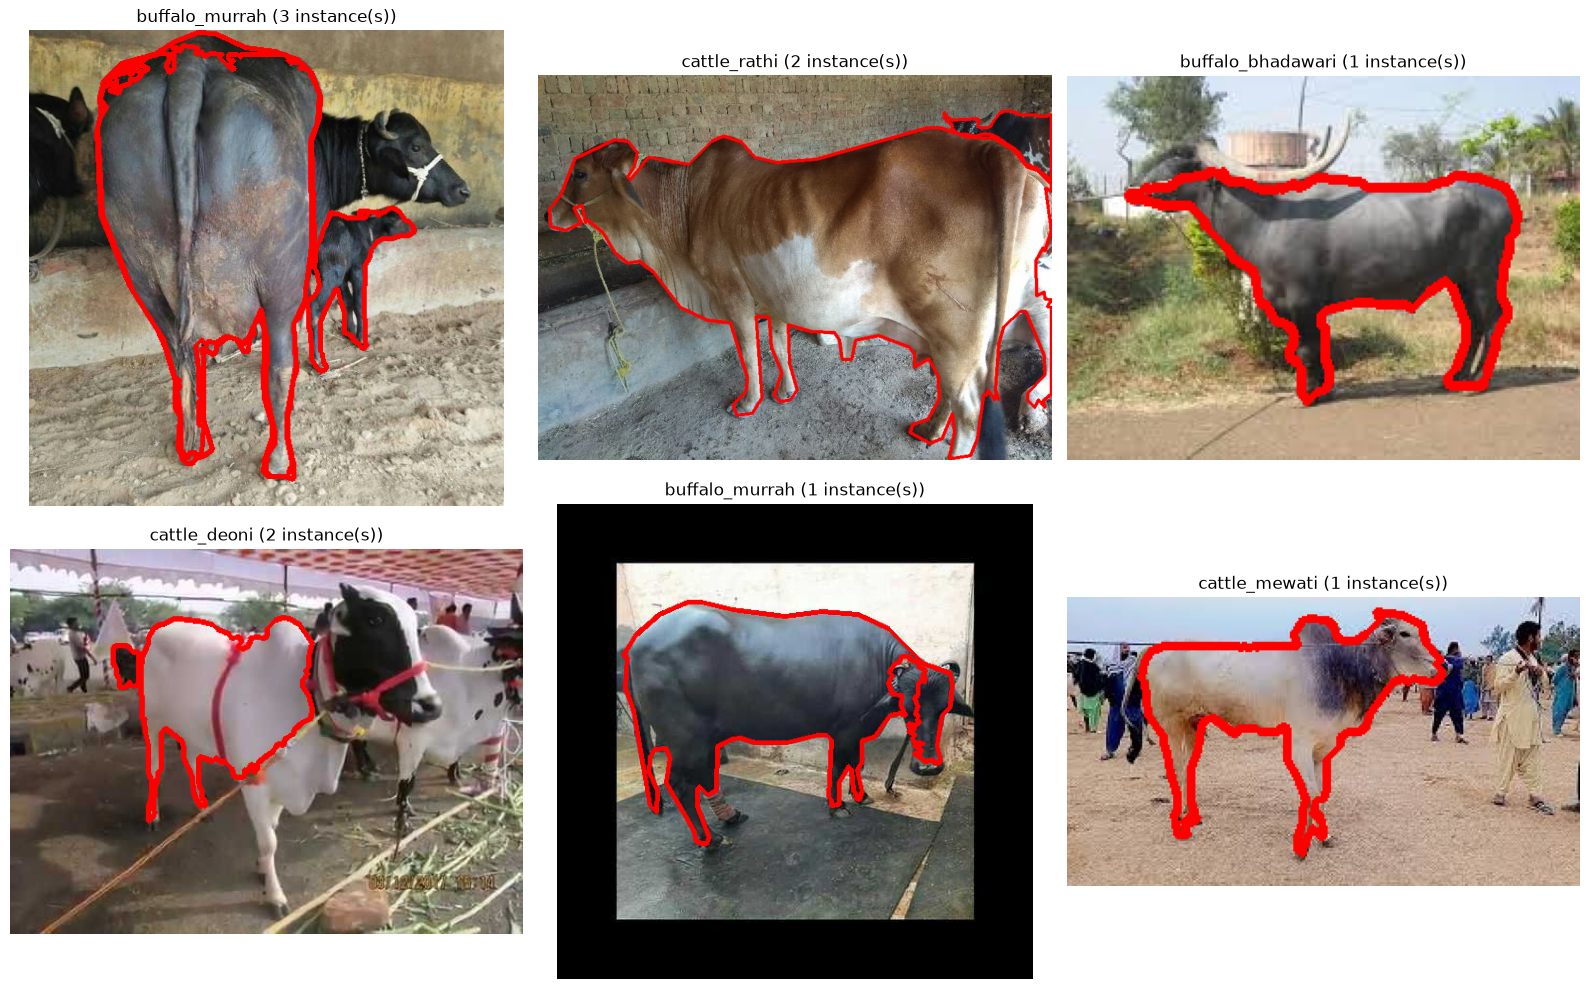

In [14]:
# -------------------------------------------------------------------
# 2. DRAW the polygon(s) on top of the image to visually verify
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, label_path in zip(axes, sample_labels):
    class_name = label_path.parent.name
    img_path = SAMPLE_DIR / class_name / f"{label_path.stem}.jpg"
    if not img_path.exists():
        # try other extensions
        for ext in [".jpeg", ".png", ".bmp"]:
            alt = SAMPLE_DIR / class_name / f"{label_path.stem}{ext}"
            if alt.exists():
                img_path = alt
                break

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        parts = list(map(float, line.strip().split()))
        cls_id = int(parts[0])
        coords = parts[1:]
        points = np.array(coords).reshape(-1, 2)
        points[:, 0] *= w
        points[:, 1] *= h
        points = points.astype(np.int32)

        cv2.polylines(img, [points], isClosed=True, color=(255, 0, 0), thickness=3)

    ax.imshow(img)
    ax.set_title(f"{class_name} ({len(lines)} instance(s))")
    ax.axis("off")

plt.tight_layout()
plt.savefig(LABELS_OUT_DIR / "sanity_check_sample.png", dpi=120)
plt.show()

In [15]:
# Check the buffalo_murrah image that showed 3 instances
for label_path in sample_labels:
    if "buffalo_murrah" in str(label_path) or "cattle_rathi" in str(label_path):
        print(f"\n=== {label_path.name} ({label_path.parent.name}) ===")
        with open(label_path) as f:
            lines = f.readlines()
        print(f"Number of instance lines: {len(lines)}")
        for i, line in enumerate(lines):
            parts = line.strip().split()
            print(f"  Instance {i}: class_id={parts[0]}, num_points={(len(parts)-1)//2}")


=== Murrah_58.txt (buffalo_murrah) ===
Number of instance lines: 3
  Instance 0: class_id=4, num_points=113
  Instance 1: class_id=4, num_points=70
  Instance 2: class_id=4, num_points=124

=== 00000310.txt (cattle_rathi) ===
Number of instance lines: 2
  Instance 0: class_id=21, num_points=111
  Instance 1: class_id=21, num_points=86

=== murrah_0153.txt (buffalo_murrah) ===
Number of instance lines: 1
  Instance 0: class_id=4, num_points=111


In [17]:
# -------------------------------------------------------------------
# 1. IDENTIFY and remove zero-detection images (and any matching stray labels)
# -------------------------------------------------------------------
removed_count = 0

for img_path_str in images_with_zero_detections:
    img_path = Path(img_path_str)
    class_name = img_path.parent.name
    label_path = LABELS_OUT_DIR / class_name / f"{img_path.stem}.txt"

    # remove the image from the annotation pool
    if img_path.exists():
        img_path.unlink()
        removed_count += 1

    # remove any (likely empty) label file that may have been created for it
    if label_path.exists():
        label_path.unlink()

print(f"Removed {removed_count} zero-detection images from the annotation pool.")

Removed 185 zero-detection images from the annotation pool.


In [18]:
# -------------------------------------------------------------------
# 2. VERIFY every remaining image has a matching non-empty label file
# -------------------------------------------------------------------
remaining_images = list(SAMPLE_DIR.rglob("*.*"))
remaining_images = [f for f in remaining_images if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]

mismatched = []
for img_path in remaining_images:
    class_name = img_path.parent.name
    label_path = LABELS_OUT_DIR / class_name / f"{img_path.stem}.txt"
    if not label_path.exists() or label_path.stat().st_size == 0:
        mismatched.append(img_path)

print(f"Remaining images: {len(remaining_images)}")
print(f"Images missing a valid label file: {len(mismatched)}")
if mismatched[:5]:
    print("Examples:", mismatched[:5])

Remaining images: 1556
Images missing a valid label file: 1
Examples: [WindowsPath('D:/B.Tech/CE-AI/Sem 7/MP/Datasets/Custom_data/seg_annotation_pool/buffalo_alambadi/Copy of Alambadi_018.jpg')]


In [19]:
img_path = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\seg_annotation_pool\buffalo_alambadi\Copy of Alambadi_018.jpg")
label_path = LABELS_OUT_DIR / "buffalo_alambadi" / f"{img_path.stem}.txt"

if img_path.exists():
    img_path.unlink()
if label_path.exists():
    label_path.unlink()

print("Removed. Final image count should now be 1555.")

Removed. Final image count should now be 1555.


In [20]:
# -------------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------------
UPLOAD_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\roboflow_upload")
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

In [21]:
# -------------------------------------------------------------------
# 2. COPY every image + its matching label file into one flat folder
#    (prefixing filenames with class name to avoid collisions across classes)
# -------------------------------------------------------------------
copied = 0
skipped = 0

for class_folder in sorted([f for f in SAMPLE_DIR.iterdir() if f.is_dir()]):
    class_name = class_folder.name
    label_folder = LABELS_OUT_DIR / class_name

    for img_path in class_folder.iterdir():
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
            continue

        label_path = label_folder / f"{img_path.stem}.txt"
        if not label_path.exists() or label_path.stat().st_size == 0:
            skipped += 1
            continue

        # prefix filenames with class name to guarantee uniqueness once flattened
        new_stem = f"{class_name}__{img_path.stem}"
        new_img_path = UPLOAD_DIR / f"{new_stem}{img_path.suffix}"
        new_label_path = UPLOAD_DIR / f"{new_stem}.txt"

        shutil.copy2(img_path, new_img_path)
        shutil.copy2(label_path, new_label_path)
        copied += 1

# also copy the classes.txt mapping file (Roboflow needs this to know class names/order)
shutil.copy2(LABELS_OUT_DIR / "classes.txt", UPLOAD_DIR / "classes.txt")

print(f"Copied {copied} image+label pairs to: {UPLOAD_DIR}")
print(f"Skipped (missing/empty label): {skipped}")

Copied 1555 image+label pairs to: D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\roboflow_upload
Skipped (missing/empty label): 0


In [22]:
# -------------------------------------------------------------------
# 3. ZIP it up for easy upload
# -------------------------------------------------------------------
zip_path = shutil.make_archive(
    str(UPLOAD_DIR.parent / "roboflow_upload"),
    "zip",
    root_dir=UPLOAD_DIR
)
print(f"\nZip file created at: {zip_path}")
print("This is the file you'll upload to Roboflow.")


Zip file created at: D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\roboflow_upload.zip
This is the file you'll upload to Roboflow.
